# Воронка бронирования детских мастер-классов — EDA и A/B-тест

Тот же событийный поток, что в [дашборде](https://malikasarina.github.io/masterclass-funnel/) и
в SQL-слое (`sql/queries.sql`), но посчитанный на pandas / statsmodels — как отдельная,
третья независимая реализация тех же расчётов. Совпадение цифр во всех трёх местах (JS-дашборд,
SQL, этот ноутбук) — способ проверить, что в методике нет ошибки, характерной для одного инструмента.

**Данные демонстрационные**, сгенерированы `gen_events.py` под бизнес-логику ТЗ на систему
бронирования — не реальный трафик.

Задача: где пользователи теряются на пути от каталога до оплаты, какие каналы окупаются,
насколько велик риск ошибок оплаты и помогает ли показ цены и дат в карточке (A/B-тест).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

# Палитра — те же CSS-переменные, что в index.html (светлая тема), чтобы графики
# выглядели продолжением дашборда, а не отдельным стилем.
C = dict(
    ink="#141922", ink2="#4d5665", ink3="#7b8596",
    line="#e0e4ec", surface="#ffffff", ground="#f1f3f7",
    accent="#3550c9", accent2="#6f83e0", accent_soft="#e6eafb",
    good="#16794f", warn="#a5721a", bad="#b23e2e",
)

plt.rcParams.update({
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "savefig.facecolor": C["surface"],
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink2"],
    "text.color": C["ink"], "xtick.color": C["ink3"], "ytick.color": C["ink3"],
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "font.size": 10.5, "figure.dpi": 110,
})

## 1. Загрузка событий

Один JSON-объект на событие, как его принимал бы `POST /v1/events`: `event_name`, `ts`, `user_id`,
`source.{channel,device,city}` и `properties` — конкретный набор полей зависит от типа события.

In [2]:
DATA_PATH = Path("events.json")
raw = json.loads(DATA_PATH.read_text(encoding="utf-8"))

events = pd.json_normalize(raw, sep=".")
events["ts"] = pd.to_datetime(events["ts"])
events = events.rename(columns={"source.channel": "channel", "source.device": "device", "source.city": "city"})
events["event_date"] = events["ts"].dt.date

print(f"{len(events):,} событий, {events['user_id'].nunique():,} пользователей,"
      f" период {events['ts'].min().date()} — {events['ts'].max().date()}")
events[["event_id", "event_name", "ts", "user_id", "channel", "device", "city"]].head()

2,680 событий, 640 пользователей, период 2026-07-06 — 2026-08-03


,event_id,event_name,ts,user_id,channel,device,city
0,evt_00001,catalog_view,2026-07-06 10:26:29+05:00,u_7439,referral_friend,desktop,Алматы
1,evt_00002,event_view,2026-07-06 10:29:15+05:00,u_7439,referral_friend,desktop,Алматы
2,evt_00003,experiment_exposed,2026-07-06 10:29:16+05:00,u_7439,referral_friend,desktop,Алматы
3,evt_00004,booking_started,2026-07-06 10:32:34+05:00,u_7439,referral_friend,desktop,Алматы
4,evt_00005,booking_created,2026-07-06 10:33:33+05:00,u_7439,referral_friend,desktop,Алматы


In [3]:
events["event_name"].value_counts().rename("count").to_frame()

,count
event_name,
catalog_view,640
event_view,500
experiment_exposed,500
booking_started,312
booking_created,214
payment_initiated,191
payment_success,153
booking_abandoned,69
payment_failed,49


## 2. Таблица по пользователям

Аналог `USERS` в дашборде и запроса `user_status` в SQL: один пользователь — одна строка, статус —
по приоритету событий (оплата важнее ошибки, ошибка важнее ожидания и т.д. — так же считает дашборд).

In [4]:
STEPS = ["catalog_view", "event_view", "booking_started", "booking_created",
         "payment_initiated", "payment_success"]

STATUS_PRIORITY = [
    ("paid", "payment_success"), ("failed", "payment_failed"), ("expired", "booking_expired"),
    ("pending", "payment_initiated"), ("reserved", "booking_created"), ("sold_out", "booking_rejected"),
    ("abandoned", "booking_abandoned"), ("started", "booking_started"), ("viewed", "event_view"),
]


def user_status(reached: set) -> str:
    for status, ev in STATUS_PRIORITY:
        if ev in reached:
            return status
    return "catalog"


def first_notna(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else None


props = pd.json_normalize(raw, sep=".")[[c for c in pd.json_normalize(raw, sep=".").columns if c.startswith("properties.")]]
props.columns = [c.removeprefix("properties.") for c in props.columns]
ev = pd.concat([events, props], axis=1)

grouped = ev.sort_values("ts").groupby("user_id")
users = grouped.agg(
    channel=("channel", "first"), device=("device", "first"), city=("city", "first"),
    first_catalog_view=("ts", "first"),
    workshop_title=("workshop_title", first_notna),
    amount_kzt=("amount_kzt", lambda s: first_notna(s.where(ev.loc[s.index, "event_name"] == "payment_success"))),
    variant=("variant", first_notna),
    n_events=("event_id", "count"),
).reset_index()
users["amount_kzt"] = users["amount_kzt"].fillna(0)

reached = grouped["event_name"].agg(set)
users["reached"] = users["user_id"].map(reached)
users["depth"] = users["reached"].apply(lambda r: sum(s in r for s in STEPS))
users["status"] = users["reached"].apply(user_status)

assert len(users) == 640, f"ожидалось 640 пользователей, получили {len(users)}"
users["status"].value_counts()

status
viewed       188
paid         153
catalog      140
abandoned     69
failed        38
sold_out      29
expired       23
Name: count, dtype: int64

## 3. Воронка

Шаг воронки — уникальные `user_id`, у которых есть событие этого шага; конверсия шага —
`users[n] / users[n-1]`, сквозная — `payment_success / catalog_view`.

In [5]:
STEP_LABELS = {
    "catalog_view": "Просмотр каталога", "event_view": "Карточка мастер-класса",
    "booking_started": "Открыл форму брони", "booking_created": "Бронь создана",
    "payment_initiated": "Начал оплату", "payment_success": "Оплачено",
}

funnel = pd.DataFrame({
    "step": STEPS,
    "label": [STEP_LABELS[s] for s in STEPS],
    "users": [users["reached"].apply(lambda r: s in r).sum() for s in STEPS],
})
funnel["step_cr_pct"] = (100 * funnel["users"] / funnel["users"].shift()).round(1)
funnel["cum_cr_pct"] = (100 * funnel["users"] / funnel["users"].iloc[0]).round(1)
funnel

,step,label,users,step_cr_pct,cum_cr_pct
0,catalog_view,Просмотр каталога,640,NaN,100.0
1,event_view,Карточка мастер-класса,500,78.1,78.1
2,booking_started,Открыл форму брони,312,62.4,48.8
3,booking_created,Бронь создана,214,68.6,33.4
4,payment_initiated,Начал оплату,191,89.3,29.8
5,payment_success,Оплачено,153,80.1,23.9


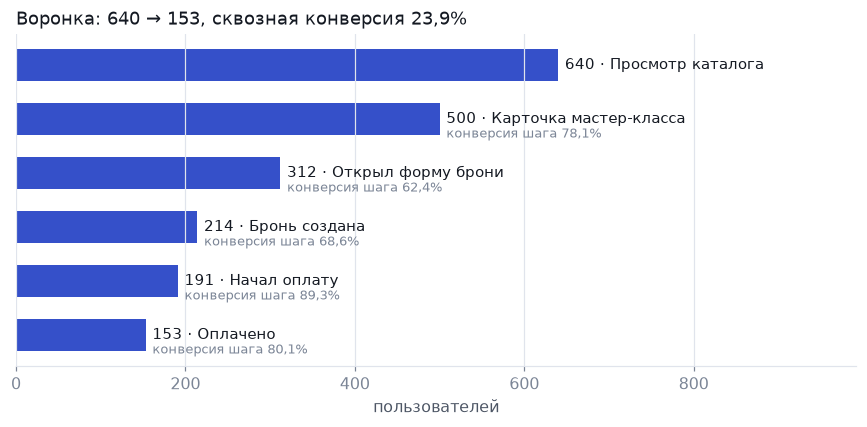

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(funnel))[::-1]
ax.barh(y, funnel["users"], color=C["accent"], height=0.6)
for yi, row in zip(y, funnel.itertuples()):
    ax.text(row.users + 8, yi, f"{row.users} · {row.label}", va="center", fontsize=10, color=C["ink"])
    if not np.isnan(row.step_cr_pct):
        ax.text(row.users + 8, yi - 0.28, f"конверсия шага {row.step_cr_pct}%".replace(".", ","),
                 va="center", fontsize=8.5, color=C["ink3"])
ax.set_xlim(0, funnel["users"].max() * 1.55)
ax.set_yticks([])
ax.set_xlabel("пользователей")
ax.set_title(f"Воронка: 640 → 153, сквозная конверсия {funnel['cum_cr_pct'].iloc[-1]}%".replace(".", ","),
             loc="left", fontsize=12, color=C["ink"])
plt.tight_layout()
plt.show()

In [7]:
paid = ev[ev["event_name"] == "payment_success"]
revenue_kzt = int(paid["amount_kzt"].sum())
avg_check = round(paid["amount_kzt"].mean())
print(f"Выручка: {revenue_kzt:,} ₸ ({len(paid)} оплат), средний чек {avg_check:,.0f} ₸")

Выручка: 1,038,000 ₸ (153 оплат), средний чек 6,784 ₸


## 4. Разрезы: каналы и причины потерь

### 4.1 Конверсия в оплату по каналам

In [8]:
by_channel = (
    users.groupby("channel")
    .agg(users_n=("user_id", "size"), paid=("status", lambda s: (s == "paid").sum()))
    .assign(cr_pct=lambda d: (100 * d["paid"] / d["users_n"]).round(1))
    .sort_values("cr_pct", ascending=False)
)
by_channel

,users_n,paid,cr_pct
channel,,,
organic_search,137,42,30.7
referral_friend,90,24,26.7
telegram_channel,116,31,26.7
instagram_ads,187,37,19.8
email_digest,71,13,18.3
offline_flyer,39,6,15.4


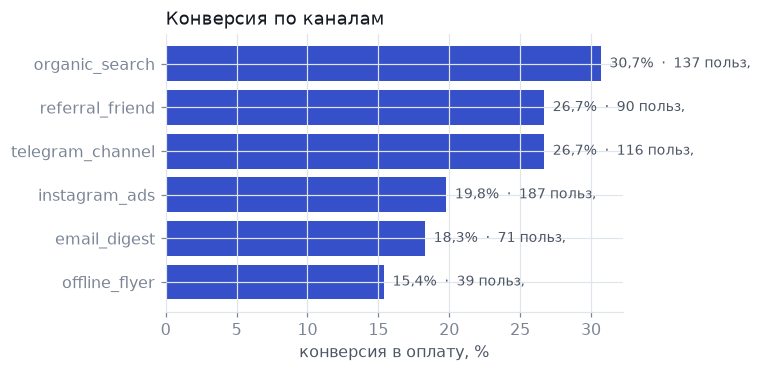

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
order = by_channel.index
ax.barh(order, by_channel["cr_pct"], color=C["accent"])
for i, (ch, row) in enumerate(by_channel.iterrows()):
    ax.text(row["cr_pct"] + 0.6, i, f"{row['cr_pct']}%  ·  {int(row['users_n'])} польз.".replace(".", ","),
            va="center", fontsize=9, color=C["ink2"])
ax.invert_yaxis()
ax.set_xlabel("конверсия в оплату, %")
ax.set_title("Конверсия по каналам", loc="left", fontsize=12, color=C["ink"])
plt.tight_layout()
plt.show()

### 4.2 Сбои оплаты

Каждый четвёртый пользователь, начавший оплату, срывается на ошибке. Смотрим структуру кодов ошибок
и помогает ли повторная попытка.

In [10]:
payment_failed = ev[ev["event_name"] == "payment_failed"]
payment_initiated_n = users["reached"].apply(lambda r: "payment_initiated" in r).sum()

failures = (
    payment_failed["error_code"].value_counts().rename("failures").to_frame()
    .assign(pct_of_initiated=lambda d: (100 * d["failures"] / payment_initiated_n).round(1))
)
print(f"Сбои оплаты: {len(payment_failed)} из {payment_initiated_n} попыток"
      f" ({100 * len(payment_failed) / payment_initiated_n:.1f}%)".replace(".", ","))
failures

Сбои оплаты: 49 из 191 попыток (25,7%)


,failures,pct_of_initiated
error_code,,
insufficient_funds,20,10.5
card_declined,12,6.3
3ds_timeout,10,5.2
gateway_timeout,7,3.7


In [11]:
retry = paid["attempt"].value_counts().sort_index()
print("Успешные оплаты по номеру попытки:")
print(retry.to_string())
print(f"\nСо второй попытки оплатили {retry.get(2, 0)} пользователей.")

Успешные оплаты по номеру попытки:
attempt
1.0    142
2.0     11

Со второй попытки оплатили 11 пользователей.


### 4.3 Потери вне оплаты: нет мест, брошенная форма, истёкшая бронь

In [12]:
drop_events = ev[ev["event_name"].isin(["booking_rejected", "booking_abandoned", "booking_expired"])]
drop_reasons = (
    drop_events.groupby(["event_name", "reason"])["user_id"].nunique()
    .rename("users").sort_values(ascending=False).reset_index()
)
drop_reasons

,event_name,reason,users
0,booking_rejected,sold_out,29
1,booking_abandoned,left_page,28
2,booking_expired,payment_timeout,23
3,booking_abandoned,changed_date,22
4,booking_abandoned,form_validation_error,19


## 5. Недельные когорты

Когорта — неделя (пн–вс) первого `catalog_view` пользователя. Доля шага считается от размера
когорты, а не от предыдущего шага — так видно, тонет ли эффективность со временем.

In [13]:
# понедельник недели, в которую попал первый визит (W-SUN period → start даёт понедельник)
users["cohort_week"] = (
    users["first_catalog_view"].dt.tz_localize(None).dt.to_period("W-SUN").apply(lambda p: p.start_time.date())
)

cohort_steps = ["event_view", "booking_started", "booking_created", "payment_initiated", "payment_success"]
cohort_labels = ["Карточка", "Форма", "Бронь", "Оплата начата", "Оплачено"]

cohort = users.groupby("cohort_week").agg(users_n=("user_id", "size"))
for step, label in zip(cohort_steps, cohort_labels):
    reached_step = users["reached"].apply(lambda r, s=step: s in r)
    cohort[label] = (100 * users.assign(r=reached_step).groupby("cohort_week")["r"].sum() / cohort["users_n"]).round(1)
cohort

,users_n,Карточка,Форма,Бронь,Оплата начата,Оплачено
cohort_week,,,,,,
2026-07-06,128,75.0,47.7,28.9,26.6,22.7
2026-07-13,160,78.1,45.0,32.5,27.5,23.1
2026-07-20,160,81.9,55.6,38.1,35.6,27.5
2026-07-27,174,77.6,47.1,33.9,29.9,22.4
2026-08-03,18,72.2,44.4,27.8,22.2,22.2


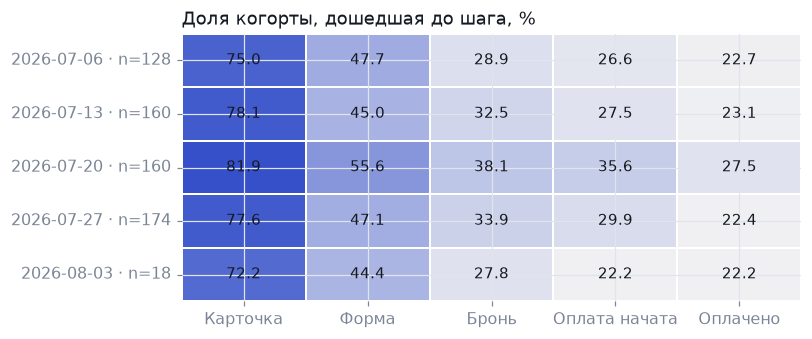

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
heat = cohort[cohort_labels]
sns.heatmap(heat, annot=True, fmt=".1f", cmap=sns.light_palette(C["accent"], as_cmap=True),
            cbar=False, linewidths=1, linecolor=C["surface"], ax=ax,
            annot_kws={"fontsize": 9.5, "color": C["ink"]})
ax.set_ylabel("")
ax.set_yticklabels([f"{d} · n={n}" for d, n in zip(cohort.index, cohort["users_n"])], rotation=0)
ax.set_title("Доля когорты, дошедшая до шага, %", loc="left", fontsize=12, color=C["ink"])
plt.tight_layout()
plt.show()

## 6. A/B-тест `card_price_dates`

Гипотеза: родитель уходит с карточки, не увидев цену и ближайшие даты. Вариант **B** показывает их
сразу на карточке. Единица анализа — пользователь с `experiment_exposed`; знаменатель — размер группы.

Тест разницы долей — двусторонний z-тест с **пулированной** дисперсией (как в дашборде и в
`sql/queries.sql`); 95% доверительный интервал разницы — на **непулированной** дисперсии (Wald),
это стандартная комбинация: тест и интервал отвечают на слегка разные вопросы и пулинг для ДИ не нужен.

In [15]:
exposed = users[users["variant"].notna()].copy()
A, B = exposed[exposed["variant"] == "A"], exposed[exposed["variant"] == "B"]
n_a, n_b = len(A), len(B)
print(f"Группа A (контроль): {n_a} польз. · Группа B (цена и даты в карточке): {n_b} польз.")

AB_METRICS = [
    ("booking_started", "Переход в форму"),
    ("booking_created", "Бронь создана"),
    ("payment_success", "Оплачено"),
]

rows = []
for step, label in AB_METRICS:
    xa = A["reached"].apply(lambda r, s=step: s in r).sum()
    xb = B["reached"].apply(lambda r, s=step: s in r).sum()
    pa, pb = xa / n_a, xb / n_b

    # пулированный z-тест — statsmodels.proportions_ztest уже делает это ровно так
    z, p = proportions_ztest([xb, xa], [n_b, n_a])

    # непулированный (Wald) ДИ разницы
    se_unpooled = np.sqrt(pa * (1 - pa) / n_a + pb * (1 - pb) / n_b)
    diff = pb - pa
    lo, hi = diff - 1.96 * se_unpooled, diff + 1.96 * se_unpooled

    rows.append(dict(metric=label, xa=xa, xb=xb, rate_a_pct=round(100 * pa, 1), rate_b_pct=round(100 * pb, 1),
                      diff_pp=round(100 * diff, 1), ci_lo_pp=round(100 * lo, 1), ci_hi_pp=round(100 * hi, 1),
                      z=round(z, 2), p=p, significant=p < 0.05))

ab = pd.DataFrame(rows)
rev_a, rev_b = A["amount_kzt"].mean(), B["amount_kzt"].mean()
print(f"Выручка на пользователя: A {rev_a:,.0f} ₸ → B {rev_b:,.0f} ₸ ({100 * (rev_b / rev_a - 1):+.1f}%)".replace(".", ","))
ab

Группа A (контроль): 255 польз. · Группа B (цена и даты в карточке): 245 польз.
Выручка на пользователя: A 1,857 ₸ → B 2,304 ₸ (+24,1%)


,metric,xa,xb,rate_a_pct,rate_b_pct,diff_pp,ci_lo_pp,ci_hi_pp,z,p,significant
0,Переход в форму,133,179,52.2,73.1,20.9,12.6,29.2,4.8,0.0,True
1,Бронь создана,95,119,37.3,48.6,11.3,2.7,19.9,2.6,0.0,True
2,Оплачено,69,84,27.1,34.3,7.2,-0.8,15.3,1.8,0.1,False


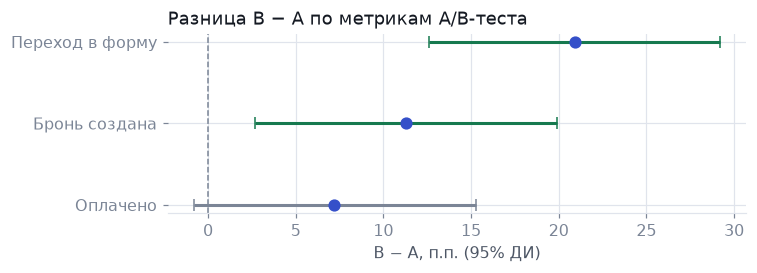

In [16]:
fig, ax = plt.subplots(figsize=(7, 2.6))
y = np.arange(len(ab))[::-1]
for yi, row in zip(y, ab.itertuples()):
    color = C["good"] if row.significant else C["ink3"]
    ax.errorbar([row.diff_pp], [yi], xerr=[[row.diff_pp - row.ci_lo_pp], [row.ci_hi_pp - row.diff_pp]],
                fmt="o", color=C["accent"], ecolor=color, elinewidth=2, capsize=4, markersize=7)
ax.axvline(0, color=C["ink3"], linewidth=1, linestyle="--")
ax.set_yticks(y, ab["metric"])
ax.set_xlabel("B − A, п.п. (95% ДИ)")
ax.set_title("Разница B − A по метрикам A/B-теста", loc="left", fontsize=12, color=C["ink"])
plt.tight_layout()
plt.show()

### Проверка сплита (SRM) и нужный размер выборки

Если механизм распределения по вариантам работает не 50/50, как задумано, весь тест под сомнением —
проверяем это χ²-тестом на сами размеры групп. Отдельно — какая выборка нужна, чтобы наблюдаемый
эффект на оплату (сейчас не значим) стал статистически надёжным при мощности 80%.

In [17]:
from scipy.stats import chisquare

n_total = n_a + n_b
chi2, p_srm = chisquare([n_a, n_b], f_exp=[n_total / 2, n_total / 2])
print(f"SRM: {n_a} / {n_b} · χ² = {chi2:.2f} · p = {p_srm:.3f}  →  "
      f"{'перекоса нет' if p_srm > 0.05 else 'подозрение на перекос сплита'}".replace(".", ","))

SRM: 255 / 245 · χ² = 0,20 · p = 0,655  →  перекоса нет


In [18]:
pay = ab[ab["metric"] == "Оплачено"].iloc[0]
p_a_pay, p_b_pay = pay["xa"] / n_a, pay["xb"] / n_b
effect_size = abs(p_b_pay - p_a_pay) / np.sqrt(((p_a_pay * (1 - p_a_pay) + p_b_pay * (1 - p_b_pay)) / 2))

analysis = NormalIndPower()
n_needed = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, ratio=1.0, alternative="two-sided")
print(f"Наблюдаемый эффект на оплату: {p_a_pay:.1%} → {p_b_pay:.1%}".replace(".", ","))
print(f"Нужно ≈ {n_needed:.0f} пользователей на вариант для мощности 80% "
      f"(сейчас {n_b} на вариант B — в {n_needed / n_b:.1f} раза меньше).".replace(".", ","))

Наблюдаемый эффект на оплату: 27,1% → 34,3%
Нужно ≈ 635 пользователей на вариант для мощности 80% (сейчас 245 на вариант B — в 2,6 раза меньше),


**Вывод:** вариант B выигрывает по основной метрике — переход в форму (p < 0,001) — и по созданию
брони (p ≈ 0,01). Эффект на оплату направленный, но на этой выборке статистически не подтверждён;
для этого нужно кратно больше пользователей на вариант. Рекомендация: раскатить B на всех и
продолжить мониторинг оплат и выручки, не дожидаясь значимости на маленькой выборке пилота.

## 7. Сверка с README и дашбордом

Тот же принцип, что в `run_sql.py`: числа, посчитанные тремя разными способами (JS-дашборд, SQL,
этот ноутбук) на одних и тех же событиях, должны совпасть. Несовпадение означало бы ошибку в одной
из трёх реализаций.

In [19]:
checks = []


def check(label, actual, expected):
    ok = actual == expected
    checks.append(ok)
    mark = "OK " if ok else "FAIL"
    print(f"[{mark}] {label}: {actual}" + ("" if ok else f"  (ожидалось {expected})"))


check("воронка, пользователи по шагам", funnel["users"].tolist(), [640, 500, 312, 214, 191, 153])
check("сквозная конверсия, %", funnel["cum_cr_pct"].iloc[-1], 23.9)
check("выручка, ₸ / средний чек, ₸", (revenue_kzt, avg_check), (1_038_000, 6784))
check("канал organic_search, CR %", by_channel.loc["organic_search", "cr_pct"], 30.7)
check("сбои оплаты, всего", len(payment_failed), 49)
check("оплат со второй попытки", int(retry.get(2, 0)), 11)
check("когорты, размеры", cohort["users_n"].tolist(), [128, 160, 160, 174, 18])
check("A/B, размеры групп", (n_a, n_b), (255, 245))
check("A/B, переход в форму A / B, %", tuple(ab.loc[ab['metric'] == 'Переход в форму', ['rate_a_pct', 'rate_b_pct']].iloc[0]), (52.2, 73.1))
check("A/B, значимость (форма и бронь — да, оплата — нет)",
      tuple(ab.sort_values('metric', key=lambda s: s.map({'Переход в форму': 0, 'Бронь создана': 1, 'Оплачено': 2}))['significant']),
      (True, True, False))

print(f"\n{'Все сверки сошлись.' if all(checks) else f'Расхождений: {checks.count(False)}'}")
assert all(checks), "числа разошлись с README/дашбордом — см. вывод выше"

[OK ] воронка, пользователи по шагам: [640, 500, 312, 214, 191, 153]
[OK ] сквозная конверсия, %: 23.9
[OK ] выручка, ₸ / средний чек, ₸: (1038000, 6784)
[OK ] канал organic_search, CR %: 30.7
[OK ] сбои оплаты, всего: 49
[OK ] оплат со второй попытки: 11
[OK ] когорты, размеры: [128, 160, 160, 174, 18]
[OK ] A/B, размеры групп: (255, 245)
[OK ] A/B, переход в форму A / B, %: (52.2, 73.1)
[OK ] A/B, значимость (форма и бронь — да, оплата — нет): (True, True, False)

Все сверки сошлись.


## 8. Итог

- Главная потеря — переход от карточки к форме брони (62,4%): 188 из 500 пользователей не доходят
  до формы за один шаг.
- Каждый четвёртый, кто начал оплату, срывается на ошибке (25,7%); повторная попытка спасает не всех.
- Каналы различаются вдвое по конверсии в оплату — органический поиск (30,7%) против офлайн-флаера
  (15,4%); у Instagram Ads много трафика при конверсии ниже среднего.
- Воронка стабильна от недели к неделе — потери системные, а не эффект отдельной кампании.
- A/B-тест `card_price_dates`: показ цены и дат в карточке поднимает переход в форму на +20,9 п.п.
  (p < 0,001) и создание брони на +11,3 п.п. (p = 0,011); эффект на оплату (+7,2 п.п.) на этой
  выборке статистически не подтверждён — нужно ≈ 640 пользователей на вариант вместо 245.

Подробный разбор и рекомендации — в [README](README.md); тот же расчёт на SQL — в
[`sql/queries.sql`](sql/queries.sql).